In [1]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
seasons = range(2022, 2024+1)
pbp = nfl.import_pbp_data(seasons)

2022 done.
2023 done.
2024 done.
Downcasting floats.


In [3]:
pff_pass = pd.read_csv('C:/Users/conne/Football Analytics/pff_pass22-24.csv')

In [4]:
print(pff_pass.filter(like = 'grades').columns)

Index(['grades_hands_fumble', 'grades_offense', 'grades_pass', 'grades_run'], dtype='object')


In [5]:
column_names = pff_pass.columns.tolist()
print(column_names)

['player', 'player_id', 'season', 'position', 'team_name', 'player_game_count', 'accuracy_percent', 'aimed_passes', 'attempts', 'avg_depth_of_target', 'avg_time_to_throw', 'bats', 'big_time_throws', 'btt_rate', 'completion_percent', 'completions', 'declined_penalties', 'def_gen_pressures', 'drop_rate', 'dropbacks', 'drops', 'first_downs', 'franchise_id', 'grades_hands_fumble', 'grades_offense', 'grades_pass', 'grades_run', 'hit_as_threw', 'interceptions', 'passing_snaps', 'penalties', 'pressure_to_sack_rate', 'qb_rating', 'sack_percent', 'sacks', 'scrambles', 'spikes', 'thrown_aways', 'touchdowns', 'turnover_worthy_plays', 'twp_rate', 'yards', 'ypa']


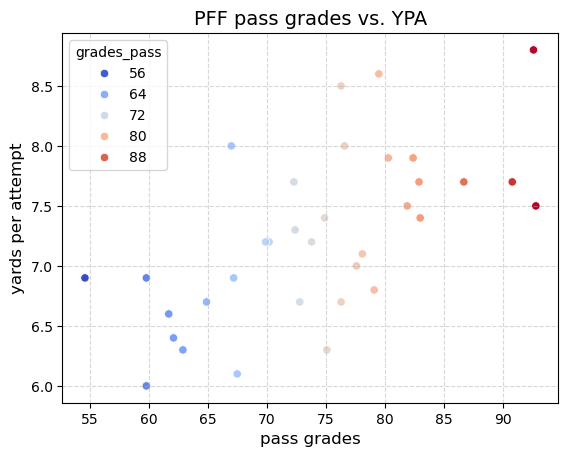

In [6]:
pff_pass_filtered = pff_pass\
    .query('attempts > 250 & season == 2024')

sns.scatterplot(data = pff_pass_filtered,
                x = 'grades_pass',
                y = 'ypa',
                hue = 'grades_pass',
                palette = 'coolwarm')

plt.title('PFF pass grades vs. YPA', fontsize = 14)
plt.xlabel('pass grades', fontsize = 12)
plt.ylabel('yards per attempt', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = .5)

plt.show()

In [7]:
pff_pass.sort_values('season', ascending = True).head(50)

,player,player_id,season,position,team_name,player_game_count,accuracy_percent,aimed_passes,attempts,avg_depth_of_target,...,sack_percent,sacks,scrambles,spikes,thrown_aways,touchdowns,turnover_worthy_plays,twp_rate,yards,ypa
312,Jack Fox,34735,2022,P,DET,1,100.0,1,1,6.0,...,0.0,0,0,0,0,0,0,0.0,6,6.0
235,Matthew Stafford,4924,2022,QB,LA,9,74.7,288,303,7.0,...,8.6,29,5,0,12,10,12,3.5,2087,6.9
236,Marcus Mariota,9435,2022,QB,ATL,13,67.3,284,300,10.5,...,7.9,28,26,4,8,15,15,4.0,2219,7.4
237,Carson Wentz,10636,2022,QB,WAS,8,73.4,256,276,7.9,...,8.3,26,12,0,10,11,14,4.2,1755,6.4
238,Taylor Heinicke,9896,2022,QB,WAS,9,71.0,231,259,9.2,...,6.5,19,13,2,15,12,19,6.3,1859,7.2
239,Zach Wilson,82096,2022,QB,NYJ,9,65.9,211,242,9.7,...,8.2,23,13,0,20,6,17,5.9,1688,7.0
240,Joe Flacco,4332,2022,QB,NYJ,5,71.7,166,191,8.4,...,5.0,10,1,0,11,5,7,3.3,1051,5.5
241,Mitch Trubisky,11757,2022,QB,PIT,7,71.3,171,180,10.0,...,5.6,11,4,1,3,4,8,3.9,1252,7.0
242,Mike White,46453,2022,QB,NYJ,4,69.6,158,175,8.0,...,4.8,9,1,0,7,3,7,3.7,1192,6.8
243,Brock Purdy,77672,2022,QB,SF,7,77.7,157,170,7.0,...,5.9,11,6,0,5,13,7,3.5,1374,8.1


In [8]:
qb_pass = pbp.query('play_type == "pass" &\
                     season_type == "REG"')

In [9]:
epa_pass = qb_pass\
    .groupby(['season','passer', 'passer_id'])\
    .agg({'epa': ['mean', 'count', 'sum']})

epa_pass.columns = list(map('_'.join, epa_pass.columns.values))

epa_pass.reset_index(inplace = True)

epa_pass = epa_pass.rename(columns = {'epa_mean': 'epa_per',
                           'epa_count': 'n',
                           'epa_sum': 'epa_total'})

epa_pass = epa_pass.query('n > 100')

print(epa_pass\
      .query('n > 100')\
      .sort_values('epa_per', ascending = False))

     season               passer   passer_id   epa_per    n   epa_total
304    2024            L.Jackson  00-0034796  0.341268  494  168.586243
124    2023              B.Purdy  00-0037834  0.296767  469  139.183517
283    2024               J.Goff  00-0033106  0.276457  568  157.027695
273    2024              J.Allen  00-0034857  0.262097  497  130.262253
88     2022            P.Mahomes  00-0033873  0.258454  677  174.973373
..      ...                  ...         ...       ...  ...         ...
325    2024            S.Rattler  00-0039376 -0.339150  250  -84.787376
146    2023              D.Jones  00-0035710 -0.344820  191  -65.860687
96     2022           S.Ehlinger  00-0036879 -0.352902  115  -40.583733
127    2023              B.Zappe  00-0038108 -0.365561  236  -86.272301
268    2024  D.Thompson-Robinson  00-0038583 -0.564612  126  -71.141144

[141 rows x 6 columns]


In [10]:
def convert_name(name):
    parts = name.strip().split()
    if len(parts) < 2:  # Ensure there are at least two parts
        return None
    return f"{parts[0][0].upper()}.{parts[-1].capitalize()}"

pff_pass['passer'] = pff_pass['player'].apply(convert_name)

pff_epa = pd.merge(pff_pass, epa_pass, 
                   on= ['passer', 'season'], 
                   how='inner')

pff_epa.drop(columns=['passer'], inplace=True)

print(pff_epa\
      .query('n > 100')\
      .sort_values('epa_per', ascending = False))

              player  player_id  season position team_name  player_game_count  \
15     Lamar Jackson      46416    2024       QB       BLT                 17   
60       Brock Purdy      77672    2023       QB        SF                 16   
9         Jared Goff      10635    2024       QB       DET                 17   
13        Josh Allen      46601    2024       QB       BUF                 16   
88   Patrick Mahomes      11765    2022       QB        KC                 17   
..               ...        ...     ...      ...       ...                ...   
80    Trevor Siemian       9683    2023       QB       NYJ                  5   
35   Spencer Rattler      97408    2024       QB        NO                  7   
79      Daniel Jones      39395    2023       QB       NYG                  6   
131     Sam Ehlinger      60555    2022       QB       IND                  4   
73      Bailey Zappe      60396    2023       QB        NE                 10   

     accuracy_percent  aime

In [12]:
pff_epa.sort_values('season', ascending = True).head(50)

,player,player_id,season,position,team_name,player_game_count,accuracy_percent,aimed_passes,attempts,avg_depth_of_target,...,thrown_aways,touchdowns,turnover_worthy_plays,twp_rate,yards,ypa,passer_id,epa_per,n,epa_total
131,Sam Ehlinger,60555,2022,QB,IND,4,71.1,97,101,7.8,...,2,3,4,3.0,573,5.7,00-0036879,-0.352902,115,-40.583733
105,Kyler Murray,38334,2022,QB,ARZ,11,77.0,357,390,7.2,...,19,14,18,3.8,2363,6.1,00-0035228,-0.040677,418,-17.002991
104,Dak Prescott,10769,2022,QB,DAL,12,74.4,375,394,8.7,...,11,23,18,4.0,2860,7.3,00-0033077,0.088990,414,36.841900
103,Tua Tagovailoa,60326,2022,QB,MIA,13,74.2,376,400,10.1,...,16,25,19,4.2,3548,8.9,00-0036212,0.213903,421,90.053024
102,Mac Jones,60323,2022,QB,NE,14,74.3,412,442,8.2,...,20,14,14,2.7,2997,6.8,00-0036972,-0.088555,478,-42.329357
101,Jalen Hurts,40291,2022,QB,PHI,15,78.0,418,460,8.6,...,28,22,11,1.9,3701,8.0,00-0036389,0.073348,499,36.600540
100,Matt Ryan,4317,2022,QB,IND,12,78.6,416,461,6.5,...,30,14,23,4.3,3057,6.6,00-0026143,-0.091221,502,-45.793106
99,Daniel Jones,39395,2022,QB,NYG,16,81.1,424,472,6.4,...,27,15,19,3.1,3206,6.8,00-0035710,0.009743,514,5.007864
97,Russell Wilson,7077,2022,QB,DEN,15,74.1,432,484,9.5,...,30,16,16,2.6,3538,7.3,00-0029263,-0.105690,538,-56.861153
96,Derek Carr,8671,2022,QB,LV,15,70.8,455,502,9.7,...,29,24,18,3.1,3522,7.0,00-0031280,0.024018,532,12.777682


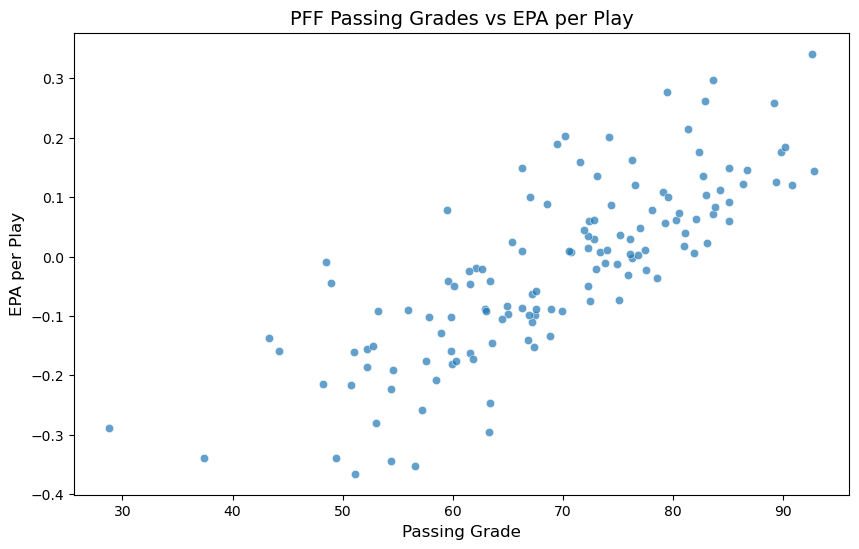

In [13]:
plt.figure(figsize = (10,6))

sns.scatterplot(data = pff_epa,
                x = 'grades_pass',
                y = 'epa_per',
                alpha = .7)

plt.title('PFF Passing Grades vs EPA per Play', fontsize = 14)
plt.xlabel('Passing Grade', fontsize=12)
plt.ylabel('EPA per Play', fontsize=12)

plt.show()


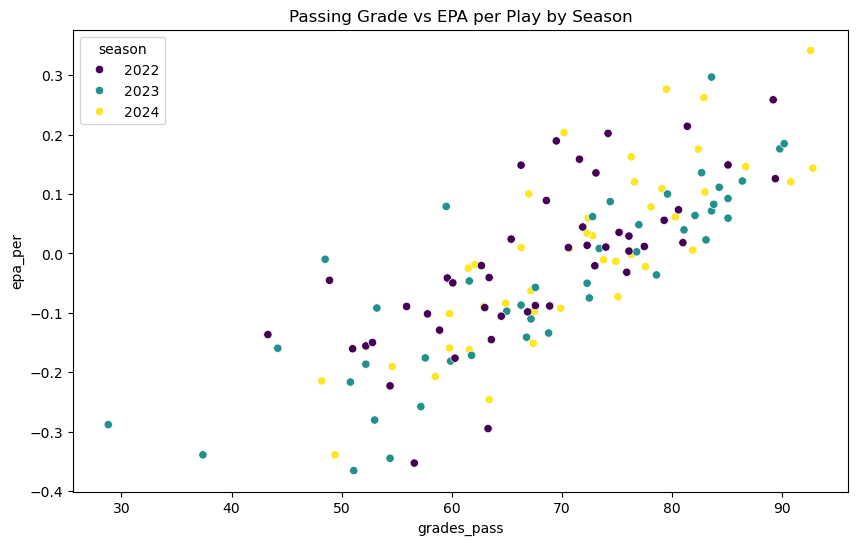

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pff_epa, x='grades_pass', y='epa_per', hue='season', palette='viridis')
plt.title('Passing Grade vs EPA per Play by Season')
plt.show()

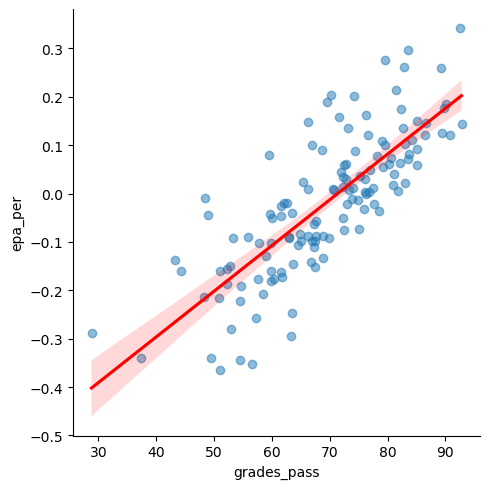

In [15]:
sns.lmplot(data = pff_epa,
           x='grades_pass',
           y='epa_per',
           scatter_kws = {'alpha':0.5},
           line_kws={'color': 'red'})

Intercept: 70.5728
Coefficient for epa_per: 66.4087
Predicted change in grades_pass for a 0.05 increase in epa_per: 3.3204


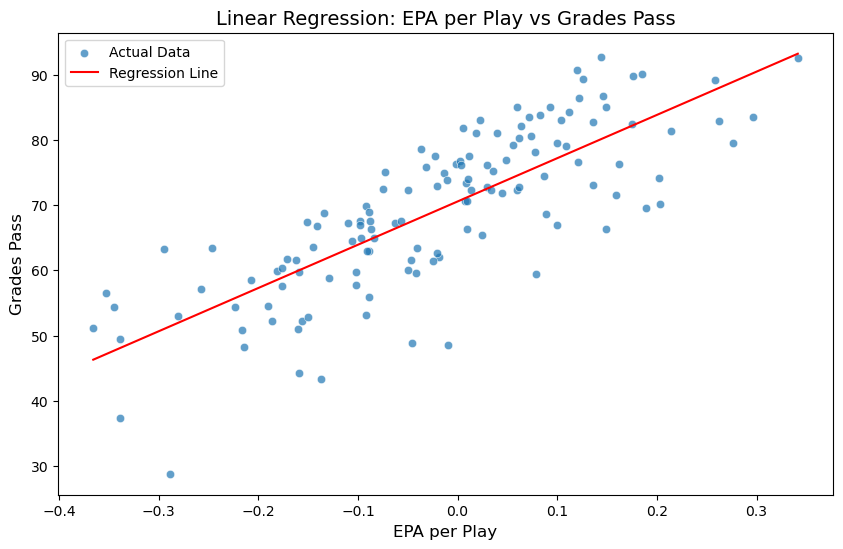

In [16]:
x = pff_epa[['epa_per']]
y = pff_epa['grades_pass']

model = LinearRegression()
model.fit(x,y)

pff_epa['predicted_grades'] = model.predict(x)

intercept = model.intercept_
coefficient = model.coef_[0]

change_in_grades_per_0_05_epa = coefficient * 0.05

print(f"Intercept: {intercept:.4f}")
print(f"Coefficient for epa_per: {coefficient:.4f}")
print(f"Predicted change in grades_pass for a 0.05 increase in epa_per: {change_in_grades_per_0_05_epa:.4f}")


plt.figure(figsize=(10, 6))
sns.scatterplot(data=pff_epa, x='epa_per', y='grades_pass', alpha=0.7, label='Actual Data')
sns.lineplot(data=pff_epa, x='epa_per', y='predicted_grades', color='red', label='Regression Line')

# Add title and labels
plt.title('Linear Regression: EPA per Play vs Grades Pass', fontsize=14)
plt.xlabel('EPA per Play', fontsize=12)
plt.ylabel('Grades Pass', fontsize=12)
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import r2_score

# Calculate the R² score
r2 = r2_score(y, pff_epa['predicted_grades'])

print(f"R² Score: {r2:.4f}")

R² Score: 0.6270
